In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# News-driven market regimes: A study on the effects of intraday market moving event arrivals on trading volume and volatility

## Table of Contents
1. [Data Loading](#Data-Loading)
2. [Event Study](#Event-study)
    * [Definition of an Event](#Definition-of-an-event)
        * [Feature Engineering](#Feature-engineering)
        * [Analyses of Shock Index Distribution](#Analyses-of-shock-index-distribution)
        * [Event Threshold Selection](#Event-threshold-selection)

---

## Data loading

In [5]:
# Market data
QQQ_5min = pd.read_csv(r'C:\Users\Raymon\QF632/Project/Aryan/fds-indx-data/indx_data/QQQ_5min.csv')
QQQ_vol = pd.read_csv(r'C:\Users\Raymon\QF632/Project/Aryan/fds-indx-data/indx_data/QQQ_volatility.csv')

In [16]:
# Tweet data
tweet_data = pd.read_csv(r'C:\Users\Raymon\QF632\Project\Aryan\fds-indx-data\Tweet data\firstsquawk_market_hours.csv')

## Part 1: Event study

### Definition of an event

#### Feature engineering

**Feature engineering**

The key point of this section is define criteria to isolate tweets that are classified as events using the data available to us i.e. price change, volatility, and trading volume.

Features:

-  Absolute log returns: Focuses purely on the magnitude of price disruptions. It treats spikes of a particular percentage as drops of the same percentage with equal weightage.
$$R_t = \left| \ln\left(\frac{\text{Close}_t}{\text{Open}_t}\right) \right|$$

-  Parkinson volatility: Captures intra period volatility i.e. price swing within the 5 min window, where standard rolling volatility would only capture volatility in close to close returns.
$$\text{Vol}_t = \frac{\left(\ln(\text{High}_t) - \ln(\text{Low}_t)\right)^2}{4 \ln 2}$$

-  Volume: Raw volume is used as a proxy for market-moving institutional re-positioning.

**Shock index**

Using fixed criteria to define events is **not a good solution given the nonstationary nature of markets**, even within the same day (e.g. volume and volatility will be higher during market open and market close, which may falsely be identified as events if we use a broad average). Therefore, features will be constructed and standardised into Z-scores with regard to **previous observations of that same 5 minute window** over the **past 20 days**. Thus, the feature Z-score for a particular 5 minute interval is a representation of how many standard deviations away from the mean over past 20 observations of that particular 5 minute interval. These Z-scores are then combined into a Shock Index which will be used in the ultimate determination of whether a movement is an event.

$$\text{Shock Index} = \sqrt{(Z_{\text{Return}})^2 + (Z_{\text{Parkinson}})^2 + (Z_{\text{Volume}})^2}$$

 
- 5 minute intervals with low Shock index Shock Index implies that it is not statistically likely for an event to have occurred.

- 5 minute intervals with higher Shock index implies that it is likely that an event has occurred given the distribution of the past 20 observations.

In [49]:
def compute_market_shocks(qqq_df, window_days=20):
    """
    This function executes feature engineering, feature z-score calculation, and computes the Shock Index 
    Input(s): qqq_df: DataFrame containing qqq OHLCV data.
              window_days: lookback period for rolling z-score calculation. Default is 20 
    Output(s): df: DataFrame with prices, engineered features, and Shock index for each interval 
    """
    df = qqq_df.copy()

    # datetime validation
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)

    # feature engineering: log returns and parkinsons volatility
    df["log_ret"] = np.abs(np.log(df["close"]) - np.log(df["open"]))
    df["park_vol"] = ((np.log(df["high"]) - np.log(df["low"])) ** 2) / (
        4 * np.log(2)
    )

    # isolate time and date of each interval for benchmarking / z-score calculation
    df["time_id"] = df["datetime"].dt.time
    df["date_id"] = df["datetime"].dt.date

    unique_times = df["time_id"].unique()

    df["z_ret"] = np.nan
    df["z_vol"] = np.nan
    df["z_park"] = np.nan

    # rolling Window Z-Score Calculation. pivot is used to create a DataFrame that has a particular metric for each interval in the 
    # columns and date in the index so that a particular metric for each interval can be compared across dates more easily.
    # architecture wise this bypasses slow for loops or groupby which is expensive computationally
    for metric in ["log_ret", "volume", "park_vol"]:
        pivot_df = df.pivot(
            index="date_id", columns="time_id", values=metric
        ).sort_index()

        # compute rolling mean and std over the previous window_days trading days
        # shift is used so that today's value is not included in the calculations for the reference baseline
        # this avoids leakage.
        rolling_mean = pivot_df.shift(1).rolling(window=window_days).mean()
        rolling_std = pivot_df.shift(1).rolling(window=window_days).std()

        # unpivot back to align with original dataframe structure
        mean_flat = rolling_mean.unstack().reset_index(name="mean_val")
        std_flat = rolling_std.unstack().reset_index(name="std_val")

        df = df.merge(
            mean_flat, on=["time_id", "date_id"], how="left"
        ).merge(std_flat, on=["time_id", "date_id"], how="left")

        z_col = (
            "z_ret"
            if metric == "log_ret"
            else ("z_vol" if metric == "volume" else "z_park")
        )
        df[z_col] = (df[metric] - df["mean_val"]) / df["std_val"].replace(
            0, np.nan
        )

        df.drop(columns=["mean_val", "std_val"], inplace=True)

    # computation of Shock index (Euclidean Distance)
    df["shock_index"] = np.sqrt(
        df["z_ret"].fillna(0) ** 2
        + df["z_vol"].fillna(0) ** 2
        + df["z_park"].fillna(0) ** 2
    )

    return df

In [51]:
QQQ_processed = compute_market_shocks(QQQ_5min)

#### Analyses of shock index distribution

In [97]:
QQQ_processed['shock_index'].describe()

count    30966.000000
mean         4.439560
std         58.017932
min          0.000000
25%          0.744502
50%          1.101940
75%          1.619631
max       5926.664757
Name: shock_index, dtype: float64

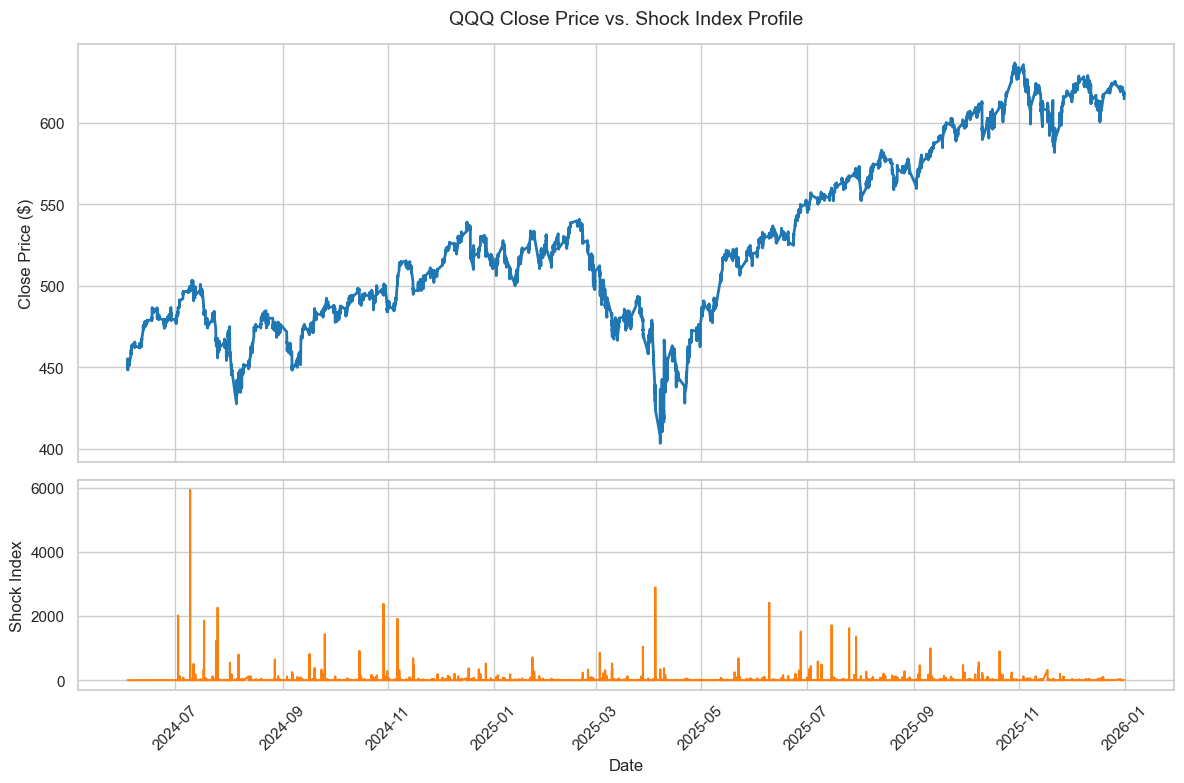

In [77]:
sns.set_theme(style="whitegrid")

# 3. Create the 2-row subplot configuration
fig, (ax1, ax2) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    figsize=(12, 8), 
    gridspec_kw={'height_ratios': [2, 1]}
)

# 4. Plot 'close' on the top subplot (ax1)
sns.lineplot(
    data=QQQ_processed, 
    x='datetime', 
    y='close', 
    ax=ax1, 
    color='#1f77b4', 
    linewidth=2
)
ax1.set_title('QQQ Close Price vs. Shock Index Profile', fontsize=14, pad=15)
ax1.set_ylabel('Close Price ($)', fontsize=12)

# 5. Plot 'shock_index' on the bottom subplot (ax2)
sns.lineplot(
    data=QQQ_processed, 
    x='datetime', 
    y='shock_index', 
    ax=ax2, 
    color='#ff7f0e', 
    linewidth=1.5
)
ax2.set_ylabel('Shock Index', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)

# 6. Rotate the date labels slightly so they don't overlap
plt.xticks(rotation=45)

# 7. Fine-tune layout and display
plt.tight_layout()
plt.show()

In [91]:
QQQ_processed['5min_interval'] = QQQ_processed['datetime'].dt.floor('5min').dt.time

# 2. Define what constitutes a "spike" (e.g., top 5% of all shocks)
shock_threshold = QQQ_processed['shock_index'].quantile(0.977)

# 3. Aggregate by interval
# We track the mean intensity, the maximum shock, and the count of actual spikes
intraday_dist = QQQ_processed.groupby('5min_interval').agg(
    mean_shock=('shock_index', 'mean'),
    max_shock=('shock_index', 'max'),
    spike_count=('shock_index', lambda x: (x > shock_threshold).sum())
).reset_index()

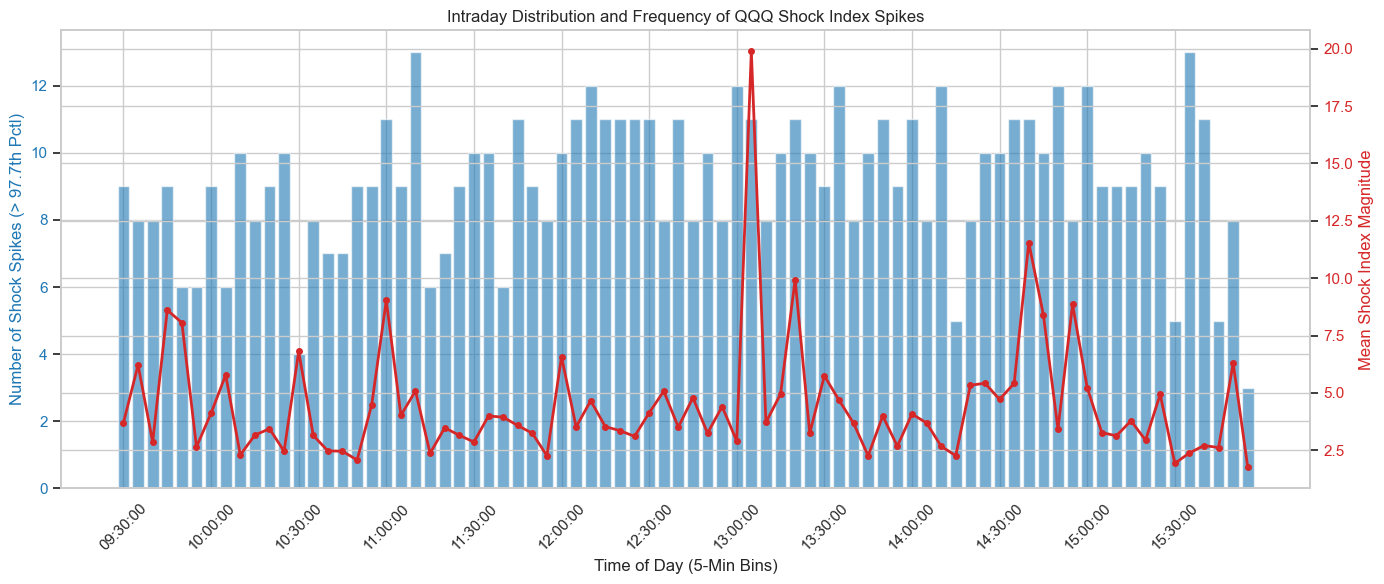

In [93]:
# Convert time objects to strings for cleaner plotting on the x-axis
intraday_dist['time_str'] = intraday_dist['5min_interval'].astype(str)

# Filter for market hours (e.g., 09:30 to 16:00) to keep the chart clean, 
# or keep the full 24h if you're looking at overnight/pre-market shocks.
market_hours = intraday_dist[
    (intraday_dist['5min_interval'] >= pd.to_datetime('09:30').time()) & 
    (intraday_dist['5min_interval'] <= pd.to_datetime('16:00').time())
]

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Frequency of spikes (Bar chart)
color = 'tab:blue'
ax1.set_xlabel('Time of Day (5-Min Bins)')
ax1.set_ylabel('Number of Shock Spikes (> 97.7th Pctl)', color=color)
bars = ax1.bar(market_hours['time_str'], market_hours['spike_count'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

# Rotate x-labels and only show every Nth label to avoid crowding
ax1.set_xticks(market_hours['time_str'][::6]) 
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Average intensity of shocks (Line chart)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Mean Shock Index Magnitude', color=color)
ax2.plot(market_hours['time_str'], market_hours['mean_shock'], color=color, linewidth=2, marker='o', markersize=4)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Intraday Distribution and Frequency of QQQ Shock Index Spikes')
fig.tight_layout()
plt.show()

Left y axis: number of times the a shock index above 95th percentile occurs in this interval.

Right y axis: mathematical average / mean value of the shock index during that 5 minute window

Interpretation:

- High bars + high line: Structurally volatile period where shocks happen frequently. When shocks have happened here, they were severe.
- High bars + low line: Market frequently crosses the threshold here but only by a small margin. This is a period of regular, minor turbulence or algo rebalancing.
- Low bars + high line: Shocks rarely happened at this time of day, but the dataset includes one or two massive anomalies which drag the average up. 

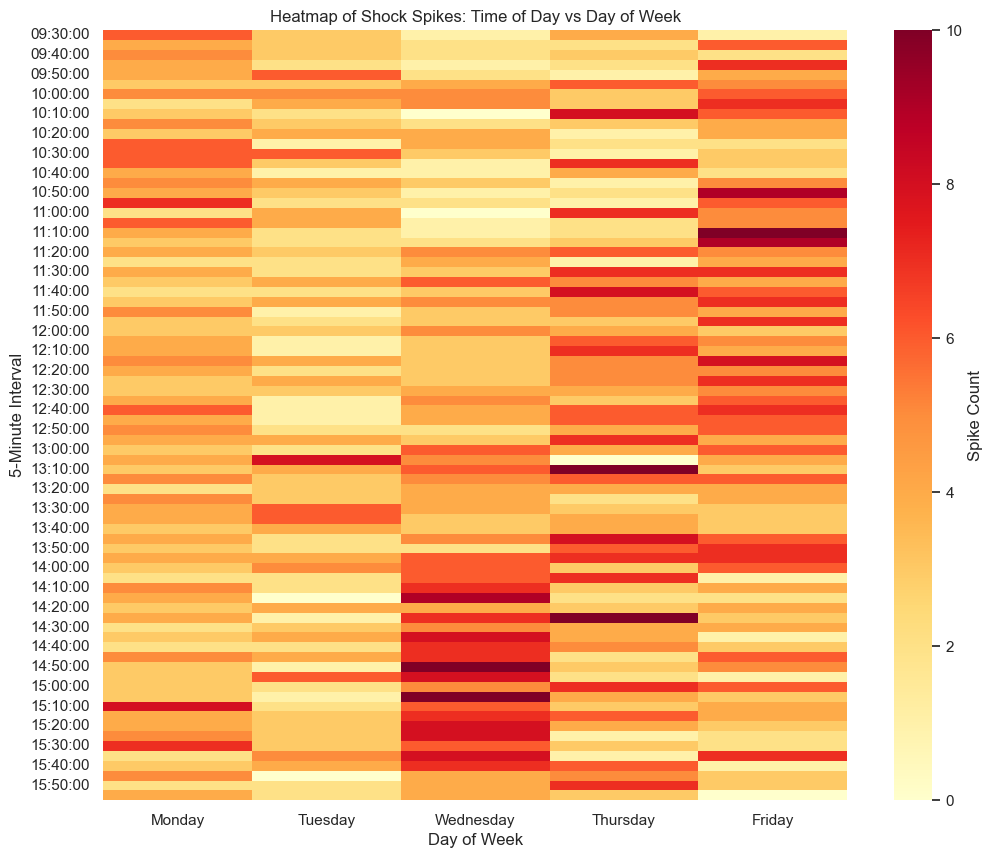

In [83]:
# Extract day of the week
QQQ_processed['day_of_week'] = QQQ_processed['datetime'].dt.day_name()

# Create a pivot table counting spikes
heatmap_data = QQQ_processed.pivot_table(
    index='5min_interval',
    columns='day_of_week',
    values='shock_index',
    aggfunc=lambda x: (x > shock_threshold).sum()
)

# Reorder columns to standard calendar order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
heatmap_data = heatmap_data.reindex(columns=days_order)

# Filter index for regular trading hours for a clearer view
market_heatmap = heatmap_data.loc[
    (heatmap_data.index >= pd.to_datetime('09:30').time()) & 
    (heatmap_data.index <= pd.to_datetime('16:00').time())
]

plt.figure(figsize=(12, 10))
sns.heatmap(market_heatmap, cmap='YlOrRd', cbar_kws={'label': 'Spike Count'})
plt.title('Heatmap of Shock Spikes: Time of Day vs Day of Week')
plt.ylabel('5-Minute Interval')
plt.xlabel('Day of Week')
plt.show()

#### Event threshold selection

Use an elbow curve to visualise how various shock-index thresholds would affect the number of events identified

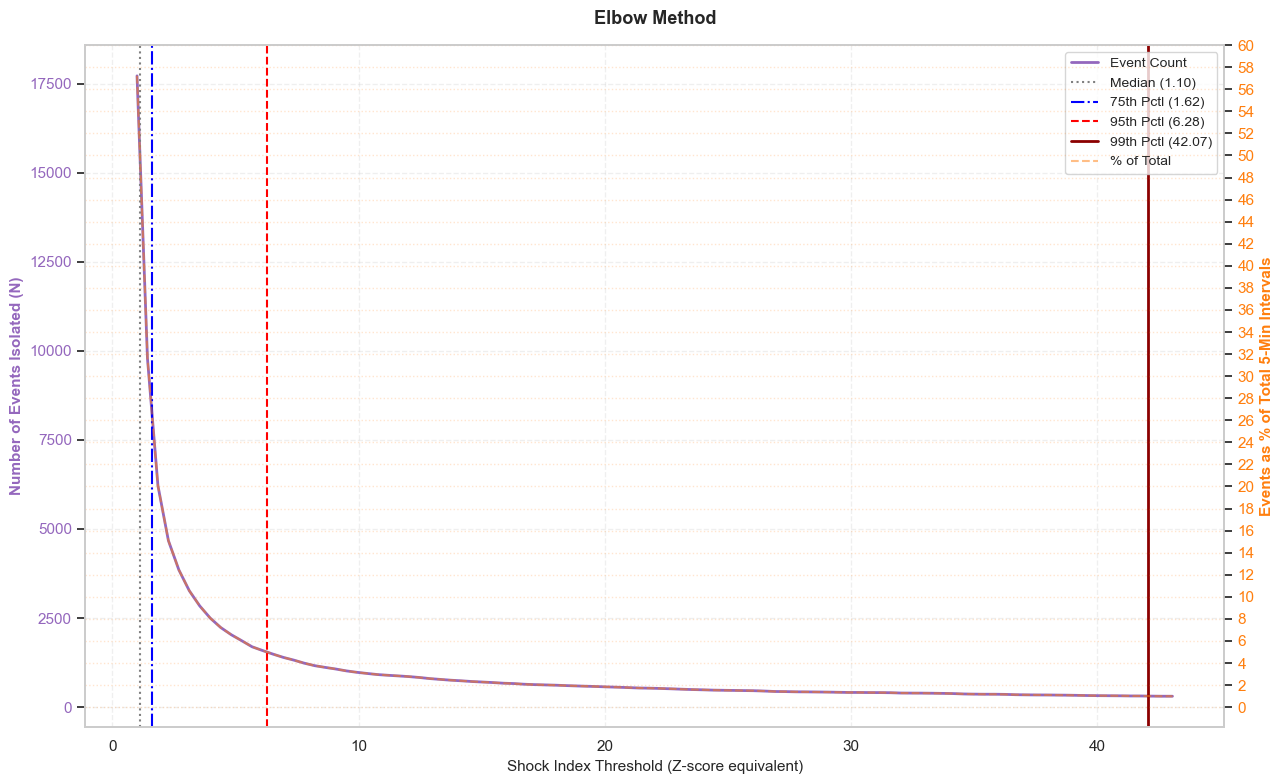

In [118]:
# 1. Calculate the exact empirical percentiles from your shock_index column
median_val = QQQ_processed['shock_index'].quantile(0.50)
p75_val = QQQ_processed['shock_index'].quantile(0.75)
p95_val = QQQ_processed['shock_index'].quantile(0.95)
p99_val = QQQ_processed['shock_index'].quantile(0.99)

# 2. Define range of thresholds to test
min_thresh = min(1.0, median_val)
max_thresh = max(6.0, p99_val + 1.0)
threshold_options = np.linspace(min_thresh, max_thresh, 100)
total_intervals = len(QQQ_processed)

# 3. Calculate absolute counts and percentages for each threshold
event_counts = [ (QQQ_processed['shock_index'] > t).sum() for t in threshold_options ]
event_percentages = [ (count / total_intervals) * 100 for count in event_counts ]

# 4. Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(13, 8))

# Left Y-Axis: Absolute Counts
color = 'tab:purple'
ax1.set_xlabel('Shock Index Threshold (Z-score equivalent)', fontsize=11)
ax1.set_ylabel('Number of Events Isolated (N)', color=color, fontsize=11, fontweight='bold')
ax1.plot(threshold_options, event_counts, color=color, linewidth=2, label='Event Count')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# Right Y-Axis: Percentage of Total Intervals
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Events as % of Total 5-Min Intervals', color=color, fontsize=11, fontweight='bold')
ax2.plot(threshold_options, event_percentages, color=color, linestyle='--', alpha=0.5, label='% of Total')
ax2.tick_params(axis='y', labelcolor=color)

# --- GRANULARITY CONFIGURATION ---
# Change the value in MultipleLocator to adjust granularity. 
# 0.5 means a tick mark every 0.5%. Use 0.25 or 0.1 for even higher resolution.
ax2.yaxis.set_major_locator(mtick.MultipleLocator(2))
#ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
# Add horizontal grid lines aligned specifically with the granular percentage ticks
ax2.grid(True, which='major', color='tab:orange', linestyle=':', alpha=0.2) 
# ---------------------------------

# 5. Add vertical reference lines for the percentiles
ax1.axvline(x=median_val, color='gray', linestyle=':', linewidth=1.5, 
            label=f'Median ({median_val:.2f})')
ax1.axvline(x=p75_val, color='blue', linestyle='-.', linewidth=1.5, 
            label=f'75th Pctl ({p75_val:.2f})')
ax1.axvline(x=p95_val, color='red', linestyle='--', linewidth=1.5, 
            label=f'95th Pctl ({p95_val:.2f})')
ax1.axvline(x=p99_val, color='darkred', linestyle='-', linewidth=2, 
            label=f'99th Pctl ({p99_val:.2f})')

# 6. Combine all labels into a single clean legend box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10, frameon=True)

plt.title('Elbow Method', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

There are a total of 78 5-minute periods in a day. Choosing a threshold that selects 5% of all total 5-minute intervals is not robust, as an event would be expected to occur every trading day.

*Calculations are based on standard US equity regular trading hours (09:30 AM – 04:00 PM EST), yielding exactly **78 five-minute periods per day**, and a standard **252 trading days per year** (19,656 total intervals).*

| Percentile | Tail Rarity (% of Total Data) | Expected Events Per Day | Expected Real-World Frequency |
| :--- | :--- | :--- | :--- |
| **95.0%** | 5.00% | 3.90 | **1 event every 0.26 days** (approx. 4 events *per day*) |
| **97.5%** | 2.50% | 1.95 | **1 event every 0.51 days** (approx. 2 events *per day*) |
| **98.7%** | 1.30% | 1.01 | **1 event every 1 trading day** |
| **99.0%** | 1.00% | 0.78 | **1 event every 1.3 trading days** |
| **99.5%** | 0.50% | 0.39 | **1 event every 2.6 trading days** |
| **99.7%** ($\approx 3\sigma$) | 0.30% | 0.23 | **1 event every 4.3 trading days** (approx. 1 per week) |
| **99.9%** | 0.10% | 0.08 | **1 event every 12.8 trading days** |
| **99.95%** | 0.05% | 0.04 | **1 event every 25.6 trading days** (approx. 1 per month) |

---

* **The Daily Baseline (98.7th Percentile):** This is the exact mathematical tipping point where an "event" is common enough to occur once per single standard trading session. Everything above this filters down into a true macro/microstructural anomaly.
* **The Event Study Sweet Spot (99.5% - 99.7%):** Setting the pipeline threshold here effectively clears out the ambient market noise. It flags true structural imbalances or liquidity shocks about 1 to 2 times a week, ensuring the isolated events are highly distinct while preserving a healthy overall sample size ($N$) across the historical backtest.

Personal thoughts: If specifically analysing the impact of intraday macro events on volume and volatility, then the threshold would be different for a non news driven regime and a news driven regime.

## Junk / Old code

In [ ]:
# 1. Calculate the exact empirical percentiles from your shock_index column
median_val = QQQ_processed['shock_index'].quantile(0.50)
p75_val = QQQ_processed['shock_index'].quantile(0.75)
p95_val = QQQ_processed['shock_index'].quantile(0.95)
p99_val = QQQ_processed['shock_index'].quantile(0.99)

# 2. Define range of thresholds to test 
# We dynamically set the range to ensure all percentiles fit nicely on the X-axis
min_thresh = min(1.0, median_val)
max_thresh = max(6.0, p99_val + 1.0)
threshold_options = np.linspace(min_thresh, max_thresh, 100)
total_intervals = len(QQQ_processed)

# 3. Calculate absolute counts and percentages for each threshold
event_counts = [ (QQQ_processed['shock_index'] > t).sum() for t in threshold_options ]
event_percentages = [ (count / total_intervals) * 100 for count in event_counts ]

# 4. Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 7))

# Left Y-Axis: Absolute Counts
color = 'tab:purple'
ax1.set_xlabel('Shock Index Threshold (Z-score equivalent)', fontsize=11)
ax1.set_ylabel('Number of Events Isolated (N)', color=color, fontsize=11, fontweight='bold')
ax1.plot(threshold_options, event_counts, color=color, linewidth=2, label='Event Count')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# Right Y-Axis: Percentage of Total Intervals
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Events as % of Total 5-Min Intervals', color=color, fontsize=11, fontweight='bold')
ax2.plot(threshold_options, event_percentages, color=color, linestyle='--', alpha=0.5, label='% of Total')
ax2.tick_params(axis='y', labelcolor=color)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

# 5. Add vertical reference lines for the percentiles
ax1.axvline(x=median_val, color='gray', linestyle=':', linewidth=1.5, 
            label=f'Median ({median_val:.2f})')
ax1.axvline(x=p75_val, color='blue', linestyle='-.', linewidth=1.5, 
            label=f'75th Pctl ({p75_val:.2f})')
ax1.axvline(x=p95_val, color='red', linestyle='--', linewidth=1.5, 
            label=f'95th Pctl ({p95_val:.2f})')
ax1.axvline(x=p99_val, color='darkred', linestyle='-', linewidth=2, 
            label=f'99th Pctl ({p99_val:.2f})')

# 6. Combine all labels into a single clean legend box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10, frameon=True)

plt.title('Elbow Method with Empirical Percentile Cutoffs', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

In [ ]:
# 1. Define range of Z-score thresholds to test
threshold_options = np.linspace(1.5, 6.0, 50)
total_intervals = len(QQQ_processed)

# 2. Calculate absolute counts and percentages for each threshold
event_counts = [ (QQQ_processed['shock_index'] > t).sum() for t in threshold_options ]
event_percentages = [ (count / total_intervals) * 100 for count in event_counts ]

# 3. Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Y-Axis: Absolute Counts
color = 'tab:purple'
ax1.set_xlabel('Shock Index Threshold (Z-score equivalent)', fontsize=11)
ax1.set_ylabel('Number of Events Isolated (N)', color=color, fontsize=11, fontweight='bold')
ax1.plot(threshold_options, event_counts, marker='o', color=color, linewidth=2, label='Event Count')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)

# Right Y-Axis: Percentage of Total Intervals
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Events as % of Total 5-Min Intervals', color=color, fontsize=11, fontweight='bold')
ax2.plot(threshold_options, event_percentages, marker='s', color=color, linestyle='--', alpha=0.7, label='% of Total')
ax2.tick_params(axis='y', labelcolor=color)

# Add a clean percentage formatting to the right axis labels
import matplotlib.ticker as mtick
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

plt.title('Elbow Method: Optimizing Shock Threshold vs. Data Proportion', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()